# Purpose of this notebook
This notebook demonstrates how to extract electrical length from unpumped S21 vs flux bias data 

# Imports
You don't need to change anything in this section. Make sure you have [xarray](https://docs.xarray.dev/en/stable/index.html) installed.

In [1]:
import logging
logging.basicConfig(level=logging.INFO,
                    format= '[%(asctime)s] %(levelname)s - [%(filename)s:%(lineno)d] %(message)s',
                    datefmt='%H:%M:%S')

import numpy as np
import xarray as xr
import os

import matplotlib.pyplot as plt

In [2]:
# Make sure electrical_length.py is in the same directory as this notebook
from electrical_length import plot_IQ, plot_electrical_length, set_units_on_plot_axis

# Load unpumped S21 vs flux data

## Load example data from AI
This subsection loads the example data provided by Arctic Instruments.
You can use this to see how the rest of the code is meant to be used,
and also to understand the format into which you should load your data.

In [3]:
netcdf_engine = None # None means that the first engine available on this system will be used.
#netcdf_engine="netcdf4" # This would be a safer choice, because the example data was saved with xr.DataSet.to_netcdf(<filename>, engine="netcdf4"), but may not be installed on your system.

s21_vs_flux = xr.open_dataset(os.path.join("example_data", "unpumped-s21-vs-flux_0.nc"), engine=netcdf_engine)

In [4]:
s21_vs_flux

<xarray.Dataset> Size: 4MB
Dimensions:    (ifbl: 301, frequency: 1500)
Coordinates:
  * ifbl       (ifbl) float64 2kB -0.0011 -0.001093 ... 0.001093 0.0011
  * frequency  (frequency) float64 12kB 3.503e+09 3.506e+09 ... 7.997e+09 8e+09
Data variables:
    magnitude  (ifbl, frequency) float32 2MB ...
    phase      (ifbl, frequency) float32 2MB ...

## Load your own gain scan data
This subsection is a placeholder for loading your own data.

How exactly you convert your data to the xarray format specified above
depends on details of your data acquisition, but it is generally not too
difficult. Here we show an example of how to convert data from raw numpy ndarrays,
which are quite easy to export from almost any measurement automation/data storage framework.

To run the example code below, change the cell type from Raw to Code.

## Define names of the coordinates and data variables in the loaded datasets

In [5]:
# These are the default names used in AI's datasets.
# If you prefer other names, change the string in quotes
# to match your names, which you can see under the Coordinates
# and Data variables sections of the datasets loaded above.

IFBL = "ifbl" # Name of flux bias current (or voltage) coordinate
FREQUENCY = "frequency" # Name of VNA frequency coordinate

MAGNITUDE_LINEAR = "magnitude" # Name of variable containing |S21| on linear scale
PHASE = "phase" # Name of variable containing arg(S21) in radians

## Convert the xr.DataSet containing magnitude and phase data variables into to a single complex S21 xr.DataArray

In [6]:
if not isinstance(s21_vs_flux, xr.DataArray): # <-- Check that this cell wasn't already run
  s21_vs_flux = s21_vs_flux[MAGNITUDE_LINEAR] * np.exp(1j*s21_vs_flux[PHASE])

# Plot the raw S21 data

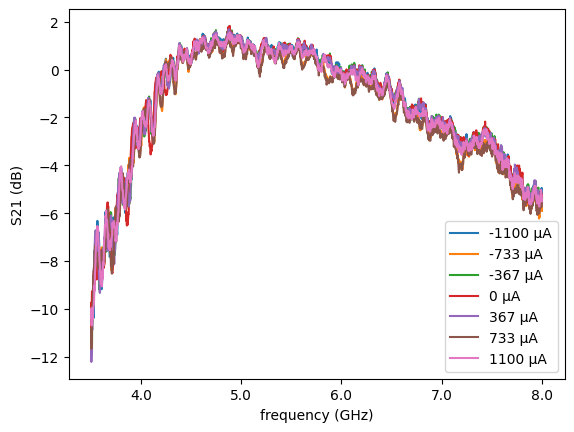

In [7]:
# Let's first plot |S21|^2 at a few flux values
fig, ax = plt.subplots()

for ifb in np.unique(s21_vs_flux[IFBL])[::50]: # <-- Adjust 50 here to be ~1/7 of the total number of flux bias points you measured, so that you plot ~7 curves
    (20*np.log10(np.abs(s21_vs_flux.sel(**{IFBL: ifb})))).plot(x=FREQUENCY,
                                                               label=f"{ifb/1e-6:.0f} µA",
                                                               ax=ax)

ax.set_title(None)
ax.set_ylabel("S21 (dB)")
set_units_on_plot_axis(ax.xaxis, 1e9, "GHz", decimals=1)
plt.legend();

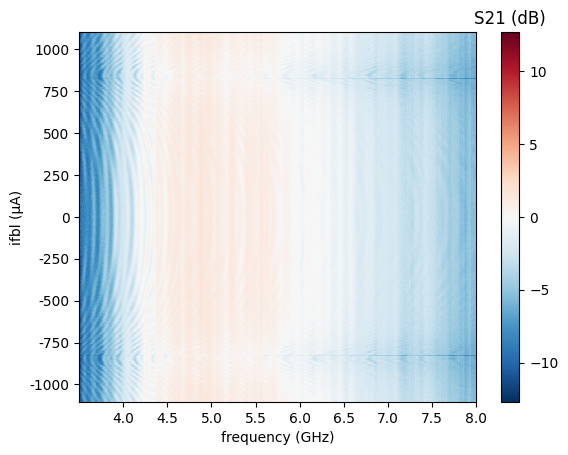

In [8]:
# Let's now plot all the flux values, this time as a heat map
fig, ax = plt.subplots()
p = (20*np.log10(np.abs(s21_vs_flux))).plot(x=FREQUENCY, y=IFBL, ax=ax)
p.colorbar.ax.set_title("S21 (dB)")
set_units_on_plot_axis(ax.xaxis, 1e9, "GHz", decimals=1)
set_units_on_plot_axis(ax.yaxis, 1e-6, "µA")

<Axes: xlabel='Re[S21]', ylabel='Im[S21]'>

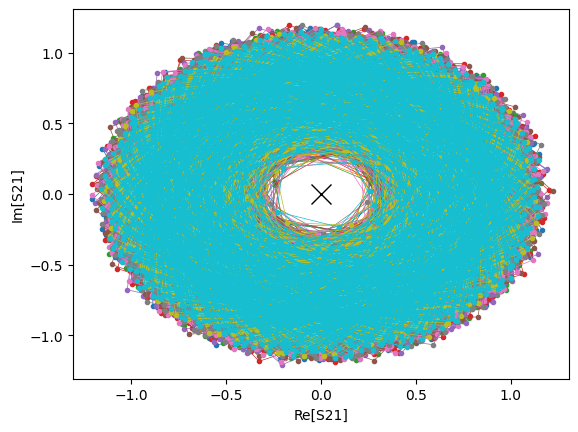

In [9]:
# This will typically look like a very thick donut, if you have a broad frequency range.
# But the origin should still be clearly visible!
plot_IQ(s21=s21_vs_flux,
        #f_min=5e9, f_max=7e9,
        max_flux_coords=11, # <-- You can decrease/increase the number of flux values being plotted here
        flux_key=IFBL, freq_key=FREQUENCY)

# Normalize the S21 data with the zero-flux response

In [10]:
smallest_flux_bias = float(np.abs(s21_vs_flux[IFBL]).min())
logging.info(f"Smallest flux bias in dataset = {smallest_flux_bias/1e-6:.1f} µA. Using that for normalization.")
assert np.abs(smallest_flux_bias) < 10e-6, "We recommend using a reference dataset where the flux bias current is zero."

reference_s21 = s21_vs_flux.sel(**{IFBL: smallest_flux_bias}).drop_vars(IFBL)
reference_s21

[14:39:05] INFO - [4152474982.py:2] Smallest flux bias in dataset = 0.0 µA. Using that for normalization.


<xarray.DataArray (frequency: 1500)> Size: 12kB
array([ 0.13585882-0.25580296j, -0.24971719-0.2093872j ,
       -0.24348055+0.19210897j, ..., -0.46831742-0.28713065j,
       -0.3743049 +0.3818461j ,  0.304236  +0.4527012j ],
      shape=(1500,), dtype=complex64)
Coordinates:
  * frequency  (frequency) float64 12kB 3.503e+09 3.506e+09 ... 7.997e+09 8e+09

In [11]:
normalized_s21_vs_flux = s21_vs_flux / reference_s21

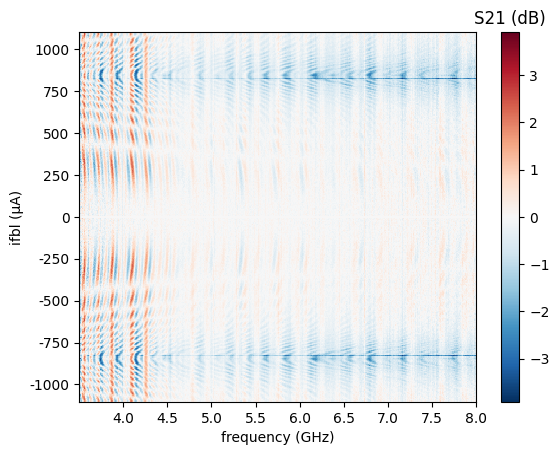

In [12]:
fig, ax = plt.subplots()
p = (20*np.log10(np.abs(normalized_s21_vs_flux))).plot(x=FREQUENCY, y=IFBL, ax=ax)
p.colorbar.ax.set_title("S21 (dB)")
set_units_on_plot_axis(ax.xaxis, 1e9, "GHz", decimals=1)
set_units_on_plot_axis(ax.yaxis, 1e-6, "µA")

# Ensure that the normalized data looks like a "thin" donut in the IQ plane

<Axes: xlabel='Re[S21]', ylabel='Im[S21]'>

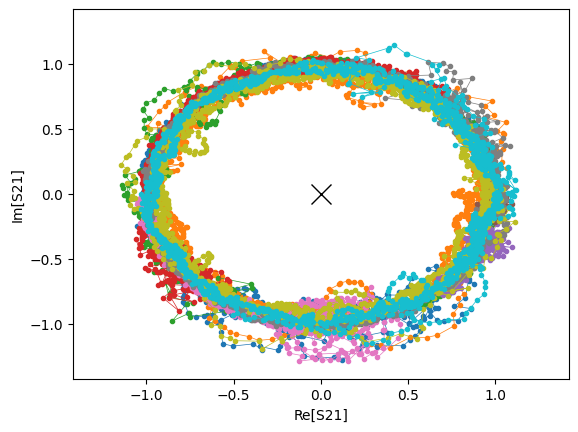

In [13]:
# After normalization, the IQ plot should look much better, in the sense of the radii of all the curves being ~1.
# There should be plenty of empty space around the origin!
plot_IQ(s21=normalized_s21_vs_flux,
        #f_min=5e9, f_max=5.5e9, # <-- You can use this to restrict the data to a range free of resonances (should be at least 500 MHz though!)
        max_flux_coords=11, # <-- You can decrease/increase the number of flux values being plotted here
        flux_key=IFBL, freq_key=FREQUENCY)

# Extract the electrical length

Peak-to-peak electrical length modulation = 1.095 ns


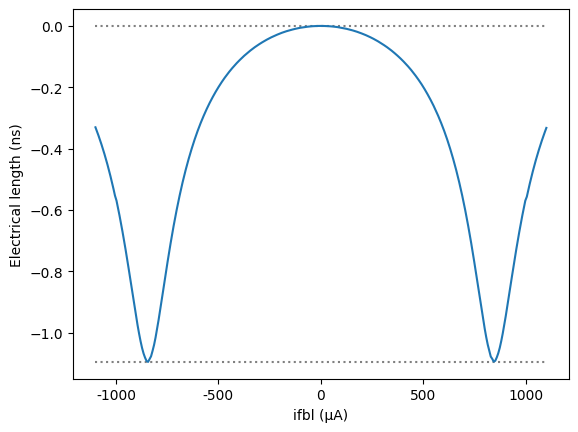

In [14]:
fig, ax = plt.subplots()
plot_electrical_length(s21=normalized_s21_vs_flux,
                       #f_min=5e9, f_max=7e9, # <-- You can use this to restrict the data to a range free of resonances (should be at least 500 MHz though!)
                       flux_key=IFBL, freq_key=FREQUENCY, ax=ax)
set_units_on_plot_axis(ax.xaxis, 1e-6, "µA")

## For comparison, see what type of artifacts you get if you restrict the signal frequency range to only 200 MHz

Peak-to-peak electrical length modulation = 1.100 ns


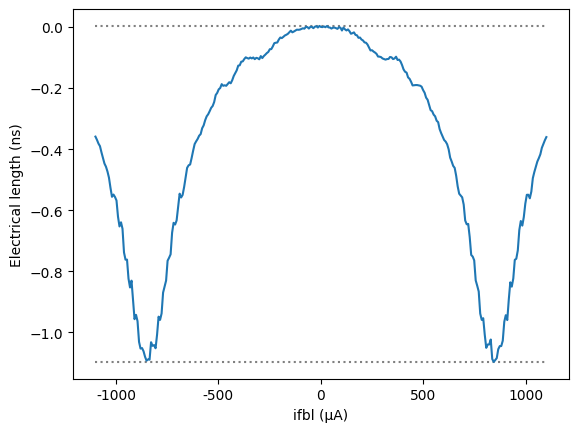

In [15]:
fig, ax = plt.subplots()
plot_electrical_length(s21=normalized_s21_vs_flux,
                       f_min=5e9, f_max=5.2e9,
                       flux_key=IFBL, freq_key=FREQUENCY, ax=ax)
set_units_on_plot_axis(ax.xaxis, 1e-6, "µA")